  group  height
0     A     3.2
1     A     3.2
2     A     3.1
3     A     2.3
4     A     2.8 

       height
group        
A          45
B          45 

         height
group          
A      2.764444
B      2.973333 



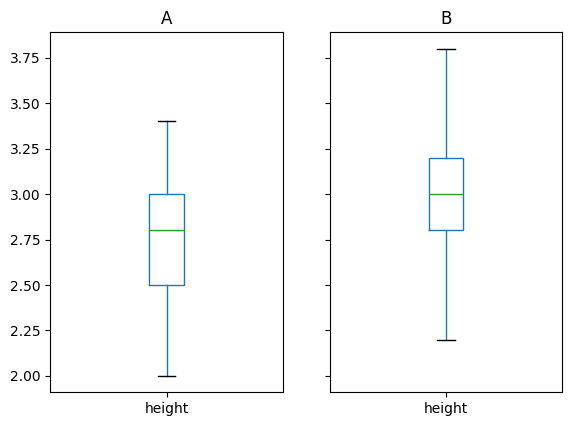

0     3.2
1     3.2
2     3.1
3     2.3
4     2.8
5     2.8
6     3.3
7     2.4
8     2.9
9     2.7
10    2.0
11    3.0
12    2.2
13    2.9
14    2.9
15    3.1
16    3.0
17    2.7
18    2.2
19    2.5
20    3.2
21    2.8
22    2.5
23    2.8
24    2.9
25    3.0
26    2.8
27    3.0
28    2.9
29    2.6
30    2.4
31    2.4
32    2.7
33    2.7
34    3.0
35    3.4
36    3.1
37    2.3
38    3.0
39    2.5
40    2.6
41    3.0
42    2.6
43    2.3
44    2.7
Name: height, dtype: float64 

45    3.3
46    2.7
47    3.0
48    2.9
49    3.0
50    3.0
51    2.5
52    2.9
53    2.5
54    3.6
55    3.2
56    2.7
57    3.0
58    2.5
59    2.8
60    3.2
61    3.0
62    3.8
63    2.6
64    2.2
65    3.2
66    2.8
67    2.8
68    2.7
69    3.3
70    3.2
71    2.8
72    3.0
73    2.8
74    3.0
75    2.8
76    3.8
77    2.8
78    2.8
79    2.6
80    3.0
81    3.4
82    3.1
83    3.0
84    3.1
85    3.1
86    3.1
87    2.7
88    3.2
89    3.3
Name: height, dtype: float64 

ShapiroResult(statistic=np.float64(0.9

In [ ]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

df = pd.read_csv("../data/ind_ttest.csv")

print(df.head(), '\n')
print(df.groupby('group').count(), '\n')
print(df.groupby('group').mean(), '\n')
df.groupby('group').boxplot(grid = False)
plt.show()

group_1 = df.loc[df.group == 'A', 'height']
group_2 = df.loc[df.group == 'B', 'height']
print(group_1, '\n')
print(group_2, '\n')

print(stats.shapiro(group_1), '\n')
print(stats.shapiro(group_2), '\n')

print(stats.levene(group_1, group_2), '\n')

result = stats.ttest_ind(group_1, group_2, equal_var = True)
print(result)

   student  before  after
0        1      63     69
1        2      65     65
2        3      56     62
3        4     100     91
4        5      88     78 

before    78.1250
after     79.4375
dtype: float64 

1.3125 



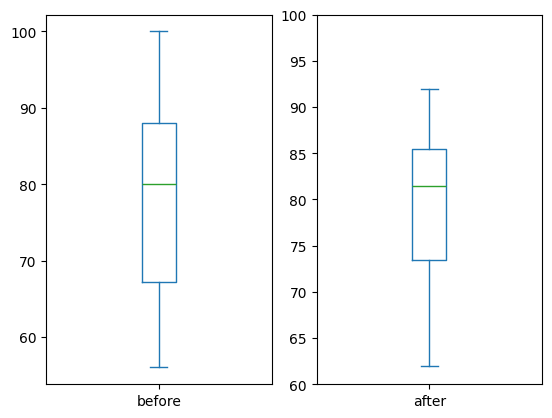

ShapiroResult(statistic=np.float64(0.9676112770019861), pvalue=np.float64(0.7985877228216062)) 

TtestResult(statistic=np.float64(-0.7497768853141169), pvalue=np.float64(0.4649871003972206), df=np.int64(15))


In [ ]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

df = pd.read_csv("../data/paired_ttest.csv")

print(df.head(), '\n')
print(df[['before', 'after']].mean(), '\n')     # 그룹별 평균
print((df['after'] - df['before']).mean(), '\n')# before, after 차이의 평균

fig, axes = plt.subplots(nrows = 1, ncols = 2)
df['before'].plot.box(grid = False, ax = axes[0])
plt.ylim([60, 100])
df['after'].plot.box(grid = False, ax = axes[1])
plt.show()

# 대응표본 t-검정 일때는 각각 정규성 검증이 아닌, 두 그룹의 차잇값에 대한 정규성 검정의 수행함(주의)
print(stats.shapiro(df['after'] - df['before']), '\n') # 정규성 검정
result = stats.ttest_rel(df['before'], df['after']) # 대응표본 t-검정
print(result)

  group  score
0     A     10
1     A     12
2     A     22
3     A     15
4     A     21 

       score
group       
A          5
B          4 

       score
group       
A      16.00
B      22.25 



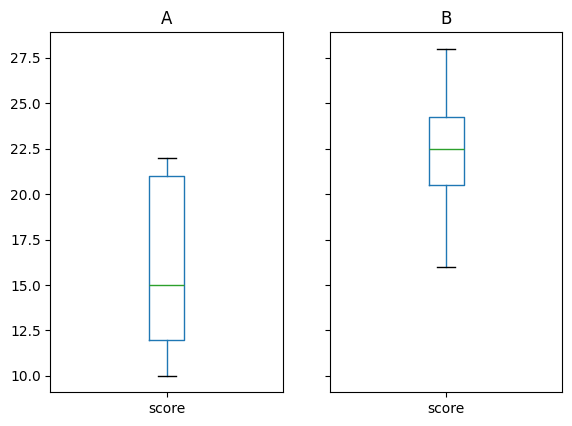

ShapiroResult(statistic=np.float64(0.903334224739142), pvalue=np.float64(0.42858737195795904)) 

ShapiroResult(statistic=np.float64(0.9730187513967565), pvalue=np.float64(0.860078521975336)) 

MannwhitneyuResult(statistic=np.float64(2.5), pvalue=np.float64(0.08509993251567075))


In [ ]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

df = pd.read_csv("../data/mw_test.csv")

print(df.head(), '\n')
print(df.groupby('group').count(), '\n')
print(df.groupby('group').mean(), '\n')
df.groupby('group').boxplot(grid = False)
plt.show()

group_1 = df.loc[df.group == "A", 'score']
group_2 = df.loc[df.group == "B", 'score']

print(stats.mannwhitneyu(group_1, group_2))

pre     79.875
post    75.375
dtype: float64 

-4.5


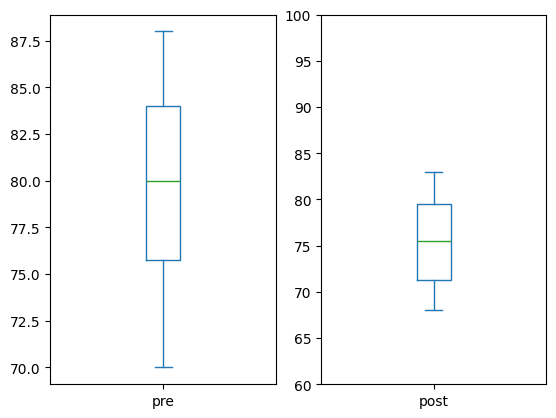

WilcoxonResult(statistic=np.float64(9.0), pvalue=np.float64(0.25))

In [10]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

df = pd.read_csv("../data/wilcoxon_test.csv")

print(df.mean(), '\n')
print((df['post'] - df['pre']).mean())

fig, axes = plt.subplots(nrows = 1, ncols = 2)
df['pre'].plot.box(grid = False, ax = axes[0])
plt.ylim([60, 100])
df['post'].plot.box(grid = False, ax = axes[1])
plt.show()

stats.wilcoxon(df['pre'], df['post'])

In [12]:
from scipy import stats

men = [10, 10]
women = [15, 65]

print(stats.chi2_contingency([men, women]))

Chi2ContingencyResult(statistic=np.float64(6.750000000000001), pvalue=np.float64(0.009374768459434897), dof=1, expected_freq=array([[ 5., 15.],
       [20., 60.]]))


In [17]:
from scipy import stats

Group_A = [7, 3]
Group_B = [2, 9]

print(stats.chi2_contingency([Group_A, Group_B])[3], '\n')

print(stats.fisher_exact([Group_A, Group_B]))

[[4.28571429 5.71428571]
 [4.71428571 6.28571429]] 

SignificanceResult(statistic=np.float64(10.5), pvalue=np.float64(0.029973122852379817))
